### 1) Problem statement
- This project will do customer segmentation based on some variables
### 2) Data collection
- Dataset Source - https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
- The data consists of 5 column and 200 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv("data/Mall_Customers.csv")

### Show Top 5 Records

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

### 2.2 Dataset information
- CustomerID
- Gender: Male or Female
- Age
- Annual Income in k$
- Spending score between 1-100

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### There is no missing values in the data set

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### Insight
- High standard deviation and wide ranges indicate strong variability, making the dataset suitable for customer segmentation.
- Since mean and median are nearly equal, the distributions appear fairly balanced without strong skewness.
- The wide spread in both income and spending suggests the presence of multiple customer groups with distinct behaviors.

### Exploring Data

In [11]:
# define numeric and categorical columns
numeric_features = [feature for feature in df.columns if pd.api.types.is_numeric_dtype(df[feature])]
categorical_features = [feature for feature in df.columns if not pd.api.types.is_numeric_dtype(df[feature])]

print(f"We have {len(numeric_features)} numeric features: {numeric_features}\n")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 4 numeric features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

We have 1 categorical features: ['Gender']


In [12]:
# ID column is not useful for analysis, so we can drop it
df.drop("CustomerID", axis=1, inplace=True)

In [13]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### Exploring Data (Visualization)

#### 4.1 Outlier detection

### Interquartile Range (IQR) Method for Outlier Detection

1. Compute **Q1 (25th percentile)** and **Q3 (75th percentile)** for the variable.

2. Compute the interquartile range (IQR):

   $$
   \text{IQR} = Q3 - Q1
   $$

3. Calculate the lower and upper bounds:

   $$
   \text{Lower Bound} = Q1 - 1.5 \times \text{IQR}
   $$

   $$
   \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}
   $$

4. Any data point outside the bounds is considered a potential outlier:

   $$
   x < \text{Lower Bound} \quad \text{or} \quad x > \text{Upper Bound}
   $$

- **Box Plot is suitable for outlier detection**

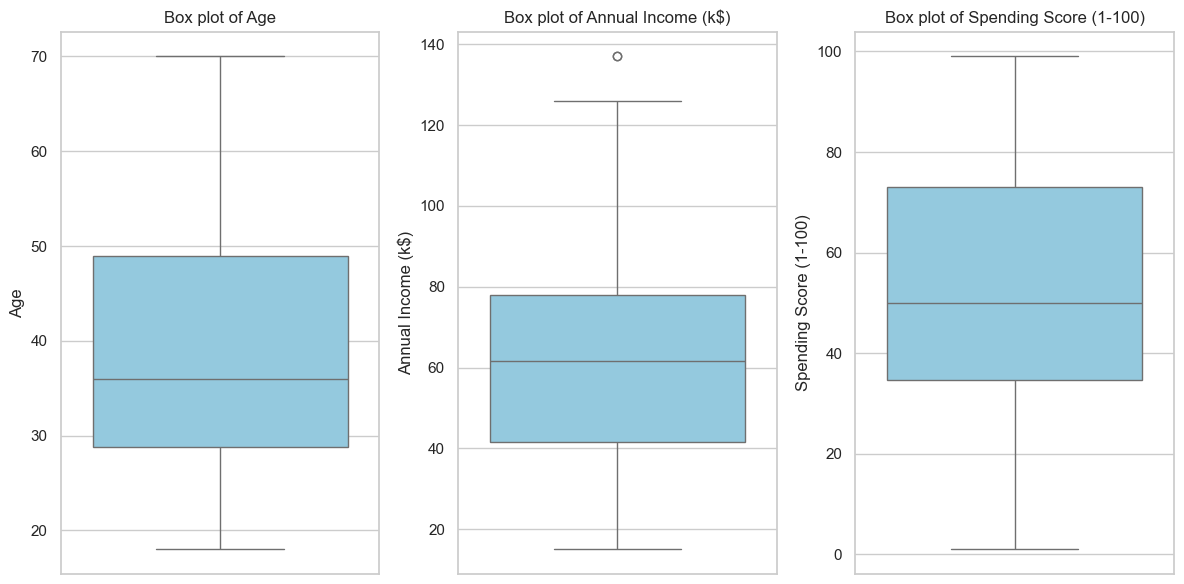

In [14]:
#draw boxplot to identify outliers
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Set style
sns.set(style="whitegrid")

# Create box plots for selected numeric columns
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

#### Insights
- From the box plot it cleared that there is no visible outlier in the dataset.

#### 4.2 Visualize the Spending score distribution

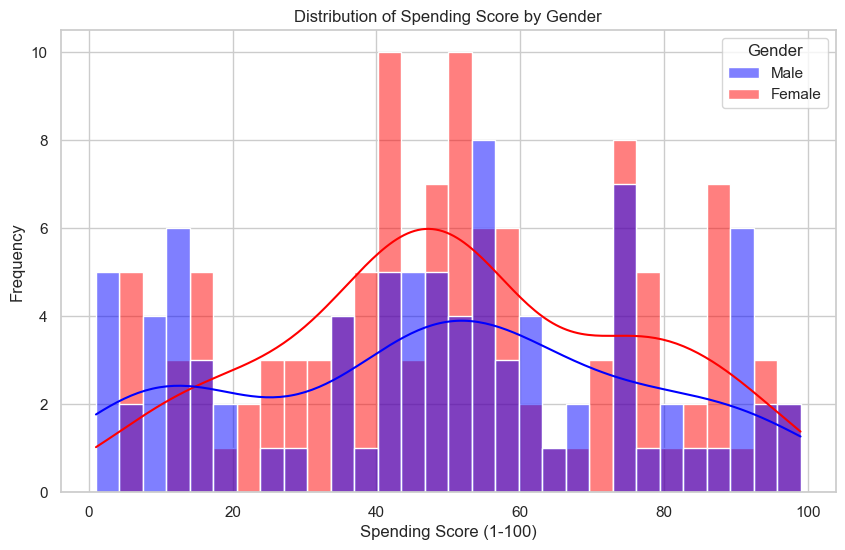

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    hue="Gender",
    kde=True,
    bins=30,
    palette={"Male": "blue", "Female": "red"}  # customize colors
)

plt.title("Distribution of Spending Score by Gender")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Frequency")

plt.show()

#### Insights
- The Spending Score is centered around the mid-range (40–60), indicating most customers have moderate spending behavior.
- Females tend to spend more compared to males.

#### 4.3 Visualize the Spending score distribution based on Annual Income

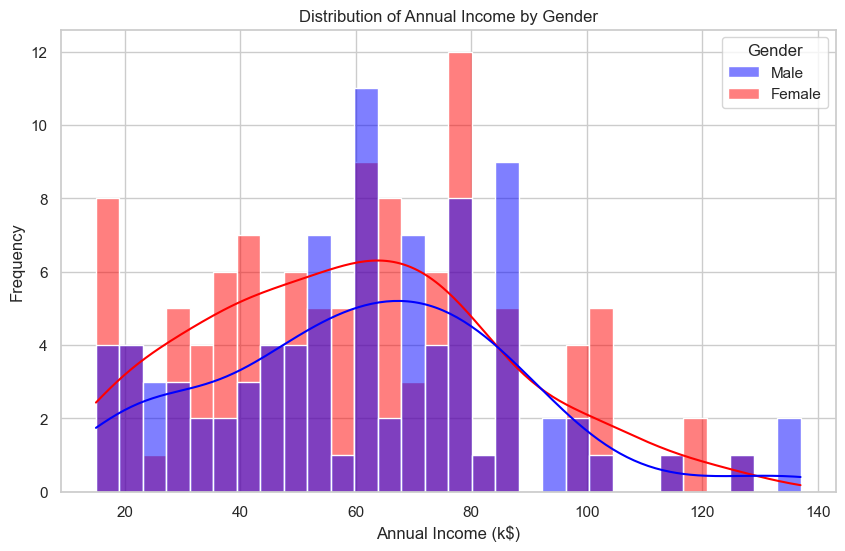

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    hue="Gender",
    kde=True,
    bins=30,
    palette={"Male": "blue", "Female": "red"}  # customize colors
)

plt.title("Distribution of Annual Income by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

#### Insights
- Most people's income below 80k$
- Female's income is greater compared to Male's income
- Most people's income fall under 50k$-80k$

#### 4.4 Scatter plot: Spending Score vs Annual Income Based on Gender

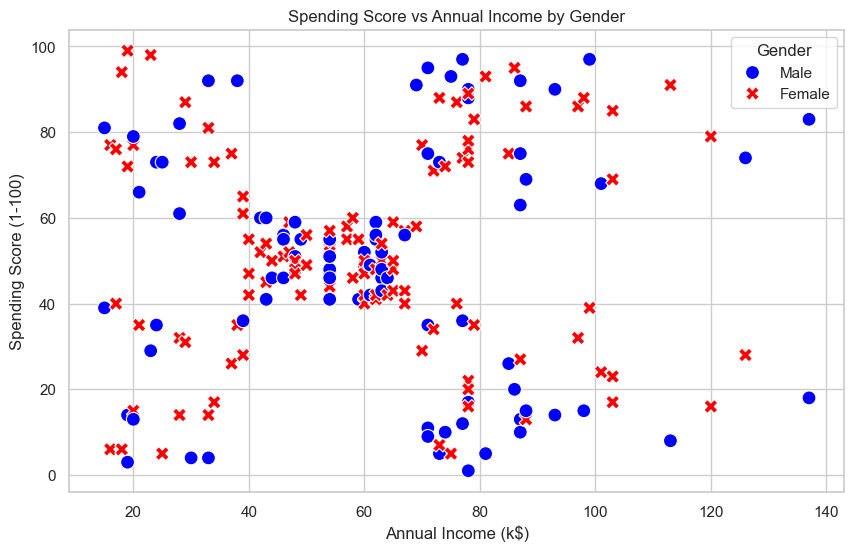

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",          # color points by gender
    style="Gender",        # optional: different markers for each gender
    palette={"Male": "blue", "Female": "red"},  # customize colors
    s=100                  # size of points
)

plt.title("Spending Score vs Annual Income by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.show()

#### Insights
- People with moderate income mostly have moderate spending scores.
- People with low or high income are more spread out; some spend very little, while others spend very much.

#### 4.5 Scatter plot: Spending Score vs Age Based on Gender

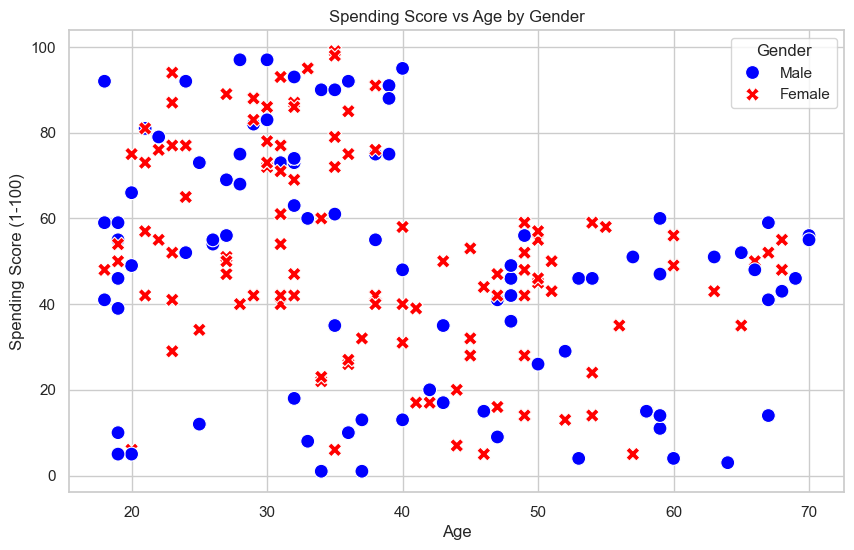

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",          # color points by gender
    style="Gender",        # optional: different markers for each gender
    palette={"Male": "blue", "Female": "red"},  # customize colors
    s=100                  # size of points
)

plt.title("Spending Score vs Age by Gender")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.show()

#### Insights
- Customers over 40 years old are predominantly economical and tend to spend a moderate amount. Their Spending Scores mostly fall between 40 and 60.
- Customers under 40 years old generally spend more actively, with Spending Scores above 40, irrespective of their income level.

#### 4.6 Scatter plot: Spending Score vs Annual Income Based on Age Category

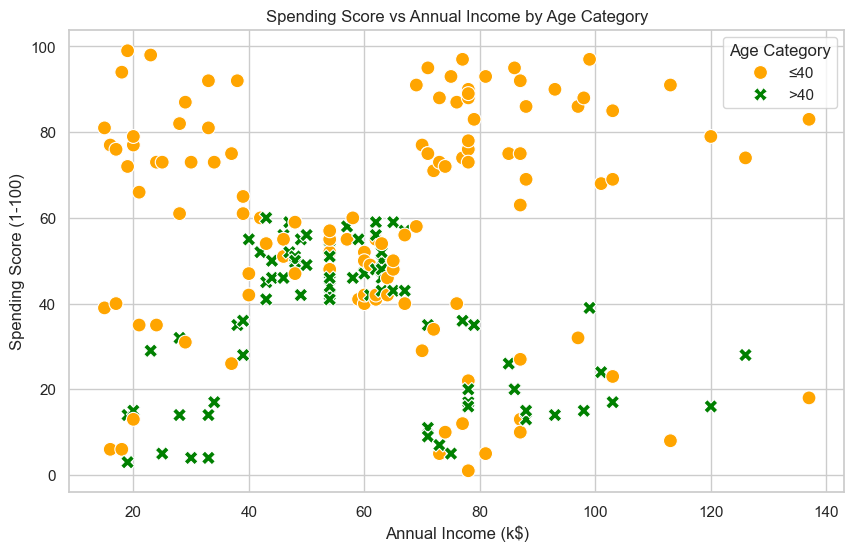

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create age categories
df['Age Category'] = pd.cut(
    df['Age'],
    bins=[0, 40, df['Age'].max()],
    labels=['≤40', '>40']
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Age Category",       # color points by age category
    style="Age Category",     # optional: different markers for each age group
    palette={'≤40': 'orange', '>40': 'green'},
    s=100
)

plt.title("Spending Score vs Annual Income by Age Category")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Age Category")
plt.show()

#### Insights
- Customers under 40 years old tend to spend more actively, regardless of their income.
- Customers with annual income between $40k and $60k generally spend a moderate amount regardless of their age

#### 4.7 Scatter plot: Spending Score vs Annual Income Based on Gender and Age Category

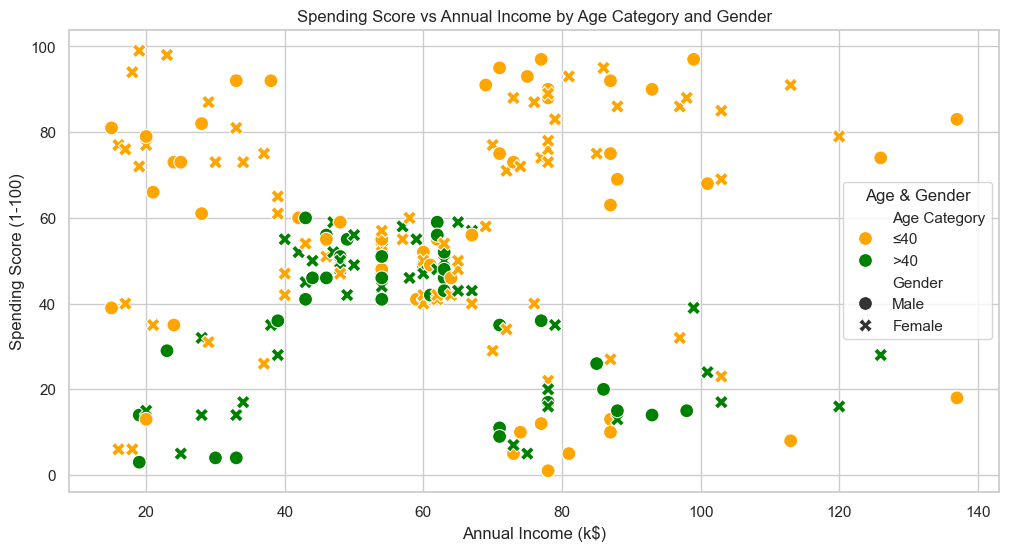

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Age Category",    # colors for age groups
    style="Gender",        # marker shape for gender
    palette={'≤40': 'orange', '>40': 'green'},
    s=100
)

plt.title("Spending Score vs Annual Income by Age Category and Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Age & Gender")
plt.show()

#### Insights
- For customers under 40 years old, gender does not significantly affect spending—both males and females tend to spend more actively.
- Customers with annual income between $40k and $60k consistently have Spending Scores between 40 and 60, regardless of gender.

#### 4.8 Univariate Analysis

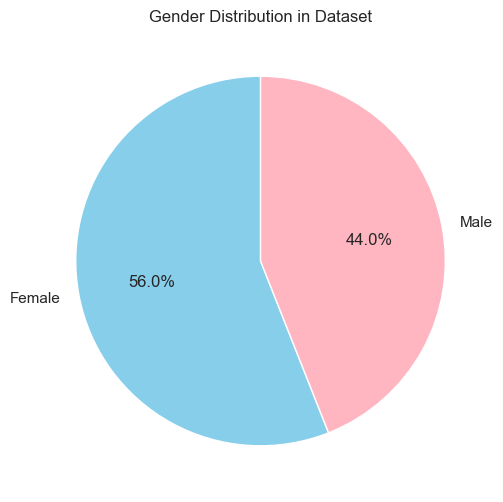

In [26]:
import matplotlib.pyplot as plt

# Count of each gender
gender_counts = df['Gender'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',  # show percentages
    startangle=90,
    colors=['skyblue', 'lightpink']
)
plt.title("Gender Distribution in Dataset")
plt.show()

#### Insights
- This is slightly skewed toward males, but it’s not heavily imbalanced.

**Rule of Thumb**
- Differences of ±5% → almost perfectly even
- Differences of 5–15% → reasonably balanced
- Differences >15% → noticeably imbalanced

## Overall Summary of EDA

The customer dataset shows clear patterns in spending behavior based on age, gender, and income:

- **Spending Score Distribution:** Most customers have a **mid spending score (40–60)**, indicating moderate spending behavior.  

- **Gender Differences:** Females tend to earn more and spend slightly more than males. However, for customers under 40, **gender does not significantly affect spending**, as both males and females spend actively.  

- **Income Patterns:** Most customers earn below $80k. Those with **mid income (40k\$–60k\$)** consistently show **mid spending scores (40–60)**, regardless of age or gender. Customers with low or high income show more variability in spending—some spend very little while others spend a lot.

- **Age Effects:** Customers over 40 are generally economical, with spending scores **never exceeding 60**, while customers under 40 are more active spenders, regardless of income level.  

- **Interactions:** Spending behavior is primarily influenced by **age and income**, with younger customers and mid-income groups showing more predictable patterns.  

**Key Takeaway:** Most moderate spenders fall into the mid-income and under-40 categories. Extreme incomes and older age groups show more varied spending, suggesting the dataset has both dense, predictable clusters and dispersed, irregular patterns.

***Probable Approach:*** K-means Clustering